In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA

In [26]:
df = pd.read_csv("../Data/humanactivity.csv")

In [3]:
df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,tBodyAcc-max()-Y,tBodyAcc-max()-Z,tBodyAcc-min()-X,tBodyAcc-min()-Y,tBodyAcc-min()-Z,tBodyAcc-sma(),tBodyAcc-energy()-X,tBodyAcc-energy()-Y,tBodyAcc-energy()-Z,tBodyAcc-iqr()-X,tBodyAcc-iqr()-Y,tBodyAcc-iqr()-Z,tBodyAcc-entropy()-X,tBodyAcc-entropy()-Y,tBodyAcc-entropy()-Z,"tBodyAcc-arCoeff()-X,1","tBodyAcc-arCoeff()-X,2","tBodyAcc-arCoeff()-X,3","tBodyAcc-arCoeff()-X,4","tBodyAcc-arCoeff()-Y,1","tBodyAcc-arCoeff()-Y,2","tBodyAcc-arCoeff()-Y,3","tBodyAcc-arCoeff()-Y,4","tBodyAcc-arCoeff()-Z,1","tBodyAcc-arCoeff()-Z,2","tBodyAcc-arCoeff()-Z,3","tBodyAcc-arCoeff()-Z,4","tBodyAcc-correlation()-X,Y","tBodyAcc-correlation()-X,Z","tBodyAcc-correlation()-Y,Z",...,fBodyBodyAccJerkMag-entropy(),fBodyBodyAccJerkMag-maxInds,fBodyBodyAccJerkMag-meanFreq(),fBodyBodyAccJerkMag-skewness(),fBodyBodyAccJerkMag-kurtosis(),fBodyBodyGyroMag-mean(),fBodyBodyGyroMag-std(),fBodyBodyGyroMag-mad(),fBodyBodyGyroMag-max(),fBodyBodyGyroMag-min(),fBodyBodyGyroMag-sma(),fBodyBodyGyroMag-energy(),fBodyBodyGyroMag-iqr(),fBodyBodyGyroMag-entropy(),fBodyBodyGyroMag-maxInds,fBodyBodyGyroMag-meanFreq(),fBodyBodyGyroMag-skewness(),fBodyBodyGyroMag-kurtosis(),fBodyBodyGyroJerkMag-mean(),fBodyBodyGyroJerkMag-std(),fBodyBodyGyroJerkMag-mad(),fBodyBodyGyroJerkMag-max(),fBodyBodyGyroJerkMag-min(),fBodyBodyGyroJerkMag-sma(),fBodyBodyGyroJerkMag-energy(),fBodyBodyGyroJerkMag-iqr(),fBodyBodyGyroJerkMag-entropy(),fBodyBodyGyroJerkMag-maxInds,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,-0.554577,-0.466223,0.717208,0.635502,0.789497,-0.877764,-0.997766,-0.998414,-0.934345,-0.975669,-0.949824,-0.830478,-0.168084,-0.378996,0.246217,0.521204,-0.487793,0.482280,-0.045462,0.211955,-0.134894,0.130858,-0.014176,-0.105971,0.073544,-0.171516,0.040063,0.076989,-0.490546,-0.709003,...,-0.484619,-1.000000,-0.035356,-0.254248,-0.700326,-0.770610,-0.797113,-0.764485,-0.820188,-0.937959,-0.770610,-0.970958,-0.798387,0.179435,-1.000000,-0.047391,-0.467849,-0.761326,-0.890165,-0.907308,-0.895301,-0.917883,-0.909829,-0.890165,-0.994105,-0.898022,-0.234815,-1.000000,0.071645,-0.330370,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978,2,STANDING
1,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,-0.554577,-0.806013,0.768031,0.683698,0.796706,-0.969097,-0.999580,-0.999646,-0.997720,-0.994006,-0.973637,-0.950720,-0.302437,-0.348243,-0.404785,0.507492,-0.156495,0.040674,0.272991,0.197566,-0.194556,0.411411,-0.340466,0.077555,-0.084024,0.035305,-0.010083,-0.104983,-0.429134,0.399177,...,-0.723642,-1.000000,-0.491213,-0.215404,-0.666004,-0.924461,-0.916774,-0.919383,-0.917983,-0.991121,-0.924461,-0.995727,-0.933127,-0.218860,-1.000000,-0.031474,-0.090655,-0.461801,-0.951977,-0.938212,-0.938008,-0.949922,-0.986902,-0.951977,-0.998272,-0.951255,-0.431053,-1.000000,-0.401189,-0.121845,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898,2,STANDING
2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,-0.568512,-0.799116,0.848305,0.667864,0.822442,-0.976782,-0.999954,-0.999570,-0.998720,-0.993456,-0.974266,-0.964976,-0.617916,-0.695490,-0.536693,0.242147,-0.114997,0.032703,0.192385,-0.011945,-0.063363,0.470819,-0.507395,0.188536,-0.231575,0.632120,-0.550708,0.305653,-0.323848,0.279786,...,-0.898000,-1.000000,0.140729,-0.206062,-0.639809,-0.975209,-0.973998,-0.967097,-0.982849,-0.997663,-0.975209,-0.999504,-0.9682

In [ ]:
df.duplicated().sum() # no duplicates

np.int64(0)

In [ ]:
df.isnull().sum().reset_index()[0].sum() # no null values in any of the columns

np.int64(0)

In [27]:
from sklearn.model_selection import train_test_split


X_train ,X_test , y_train ,y_test = train_test_split(df.drop(columns = ['Activity']) , df['Activity'] , test_size=0.2 , random_state=42)

In [28]:
#step 1 mean centering
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
pca = PCA(n_components=None)

In [30]:
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

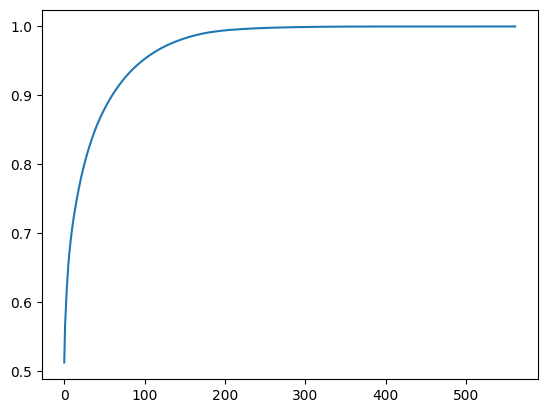

In [31]:
import matplotlib.pyplot as plt

plt.plot(np.cumsum(pca.explained_variance_ratio_))

In [ ]:
#Checking what value is good

70 components -> 0.9160 variance retained
71 components -> 0.9176 variance retained
72 components -> 0.9191 variance retained
73 components -> 0.9206 variance retained
74 components -> 0.9221 variance retained
75 components -> 0.9235 variance retained
76 components -> 0.9250 variance retained
77 components -> 0.9263 variance retained
78 components -> 0.9277 variance retained
79 components -> 0.9290 variance retained
80 components -> 0.9303 variance retained
81 components -> 0.9316 variance retained
82 components -> 0.9329 variance retained
83 components -> 0.9341 variance retained
84 components -> 0.9354 variance retained
85 components -> 0.9366 variance retained
86 components -> 0.9377 variance retained
87 components -> 0.9389 variance retained
88 components -> 0.9400 variance retained
89 components -> 0.9410 variance retained
90 components -> 0.9421 variance retained
91 components -> 0.9432 variance retained
92 components -> 0.9442 variance retained
93 components -> 0.9453 variance r

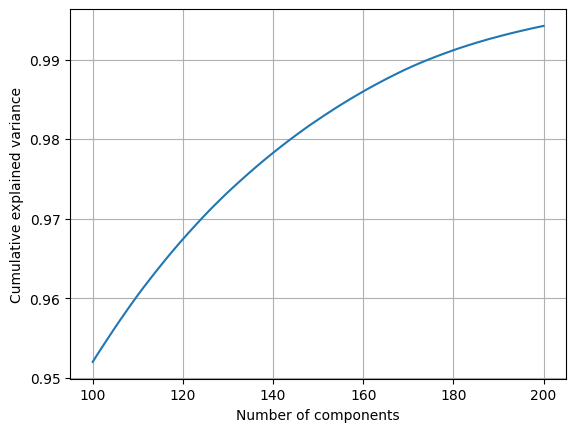

In [33]:
pca = PCA(n_components=200)
pca.fit(X_train)

cum_var = np.cumsum(pca.explained_variance_ratio_)

for n in range(70, 100):
    print(f"{n} components -> {cum_var[n-1]:.4f} variance retained")

plt.plot(range(100, 201), cum_var[99:200])
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.grid(True)
plt.show()

In [ ]:
# for the 90% Explaination rule

pca = PCA(n_components=0.90)
X_reduced = pca.fit_transform(X_train)
print(pca.n_components_)

61


In [35]:
X_test_reduced = pca.transform(X_test)

In [ ]:
# both of them are now reduced to explain 90% variance

In [37]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components= 2, perplexity= 30)

In [38]:
X_train_tsne = tsne.fit_transform(X_train)
type(X_train_tsne)

numpy.ndarray

In [39]:
tsne_df = pd.DataFrame(X_train_tsne)

In [41]:
tsne_df.columns = ['first' , 'second']

<Axes: xlabel='first', ylabel='second'>

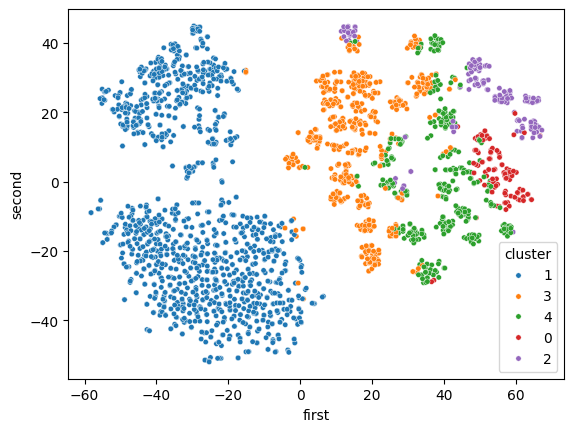

In [49]:
from sklearn.cluster import KMeans
import seaborn as sns

tsne_df["cluster"] = KMeans(n_clusters=5, random_state=42).fit_predict(X_train).astype(str)
sns.scatterplot(data=tsne_df, x="first", y="second", hue="cluster", palette="tab10", s=15)